In [7]:
# If needed:
# pip install yfinance pandas numpy matplotlib seaborn scipy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

In [8]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
    "JPM", "BAC", "GS", "MS",
    "XOM", "CVX", "COP",
    "JNJ", "PFE", "UNH",
    "PG", "KO", "PEP",
    "CAT", "BA"
]

start_date = "2015-01-01"
end_date = "2024-12-31"

In [9]:
raw_data = yf.download(tickers, start=start_date, end=end_date)
print(raw_data.columns)

[*********************100%***********************]  20 of 20 completed


MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close',    'BA'),
            ( 'Close',   'BAC'),
            ( 'Close',   'CAT'),
            ( 'Close',   'COP'),
            ( 'Close',   'CVX'),
            ( 'Close', 'GOOGL'),
            ( 'Close',    'GS'),
            ( 'Close',   'JNJ'),
            ( 'Close',   'JPM'),
            ( 'Close',    'KO'),
            ( 'Close',    'MS'),
            ( 'Close',  'MSFT'),
            ( 'Close',  'NVDA'),
            ( 'Close',   'PEP'),
            ( 'Close',   'PFE'),
            ( 'Close',    'PG'),
            ( 'Close',   'UNH'),
            ( 'Close',   'XOM'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High',    'BA'),
            (  'High',   'BAC'),
            (  'High',   'CAT'),
            (  'High',   'COP'),
            (  'High',   'CVX'),
            (  'High', 'GOOGL'),
            (  'High',    'GS'),
            (  'High',   'JNJ'),
          

In [10]:
raw_data = yf.download(tickers, start=start_date, end=end_date)

# Extract Adjusted Close safely
data = raw_data.xs("Close", level=0, axis=1)

data = data.dropna()

print("Data shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())

[*********************100%***********************]  20 of 20 completed


Data shape: (2515, 20)
Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00


In [11]:
returns = np.log(data / data.shift(1)).dropna()

print("Returns shape:", returns.shape)
returns.head()

Returns shape: (2514, 20)


Ticker,AAPL,AMZN,BA,BAC,CAT,COP,CVX,GOOGL,GS,JNJ,JPM,KO,MS,MSFT,NVDA,PEP,PFE,PG,UNH,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028576,-0.020731,-0.006950,-0.029481,-0.054231,-0.048761,-0.040792,-0.019238,-0.031721,-0.007009,-0.031537,0.000000,-0.031758,-0.009238,-0.017035,-0.007546,-0.005441,-0.004766,-0.016609,-0.027743
2015-01-06,0.000094,-0.023098,-0.011848,-0.030376,-0.006455,-0.042162,-0.000463,-0.024989,-0.020437,-0.004926,-0.026271,0.007565,-0.029223,-0.014786,-0.030787,-0.007604,0.008310,-0.004566,-0.002020,-0.005330
2015-01-07,0.013925,0.010544,0.015407,0.004734,0.015377,0.006652,-0.000834,-0.002945,0.014793,0.021836,0.001525,0.012405,0.014177,0.012625,-0.002609,0.028821,0.013593,0.005232,0.010159,0.010081
2015-01-08,0.037702,0.006813,0.017527,0.020451,0.010197,0.024635,0.022625,0.003478,0.015840,0.007832,0.022100,0.012023,0.014779,0.028994,0.036927,0.018012,0.020203,0.011370,0.046629,0.016508
2015-01-09,0.001072,-0.011818,-0.001975,-0.018092,-0.012021,-0.000154,-0.020126,-0.012287,-0.015466,-0.013723,-0.017540,-0.011093,-0.016405,-0.008441,0.004020,-0.006794,0.004605,-0.009374,-0.009404,-0.001411


In [12]:
summary_stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std Dev": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurtosis()
})

# Jarque-Bera Test
jb_results = returns.apply(lambda x: stats.jarque_bera(x)[0])
jb_pvalues = returns.apply(lambda x: stats.jarque_bera(x)[1])

summary_stats["Jarque-Bera"] = jb_results
summary_stats["JB_pvalue"] = jb_pvalues

summary_stats = summary_stats.round(5)
summary_stats

,Mean,Std Dev,Skewness,Kurtosis,Jarque-Bera,JB_pvalue
Ticker,,,,,,
AAPL,0.00093,0.01793,-0.20123,5.45738,3121.60362,0.0
AMZN,0.00106,0.02058,0.15739,5.80312,3521.04430,0.0
BA,0.00018,0.02545,-0.51141,17.57286,32319.57783,0.0
BAC,0.00044,0.01958,-0.02543,9.62497,9660.96811,0.0
CAT,0.00065,0.01879,-0.33912,4.67970,2330.66991,0.0
COP,0.00026,0.02425,-0.48505,14.73616,22747.69966,0.0
CVX,0.00027,0.01875,-0.94144,26.35891,72848.18892,0.0
GOOGL,0.00079,0.01791,0.01648,6.19588,4002.29093,0.0
GS,0.00051,0.01815,-0.09596,9.52855,9471.92557,0.0


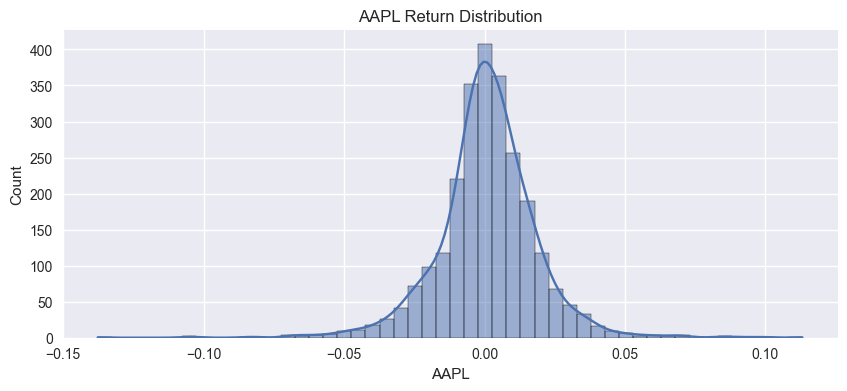

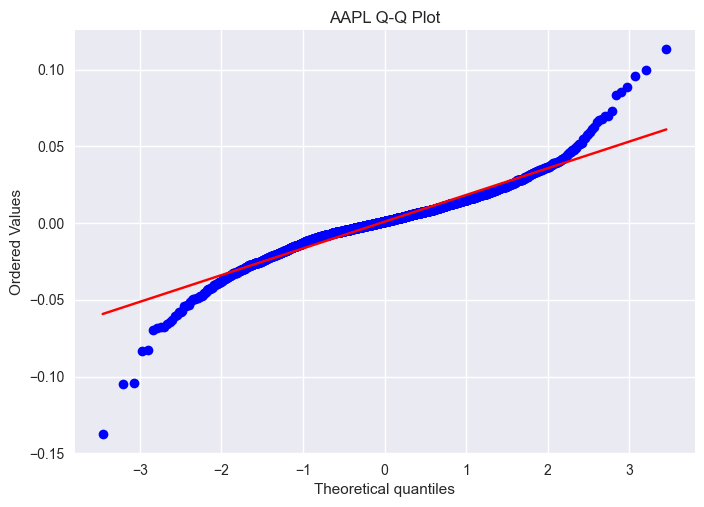

In [13]:
asset = "AAPL"

plt.figure(figsize=(10,4))
sns.histplot(returns[asset], bins=50, kde=True)
plt.title(f"{asset} Return Distribution")
plt.show()

stats.probplot(returns[asset], dist="norm", plot=plt)
plt.title(f"{asset} Q-Q Plot")
plt.show()

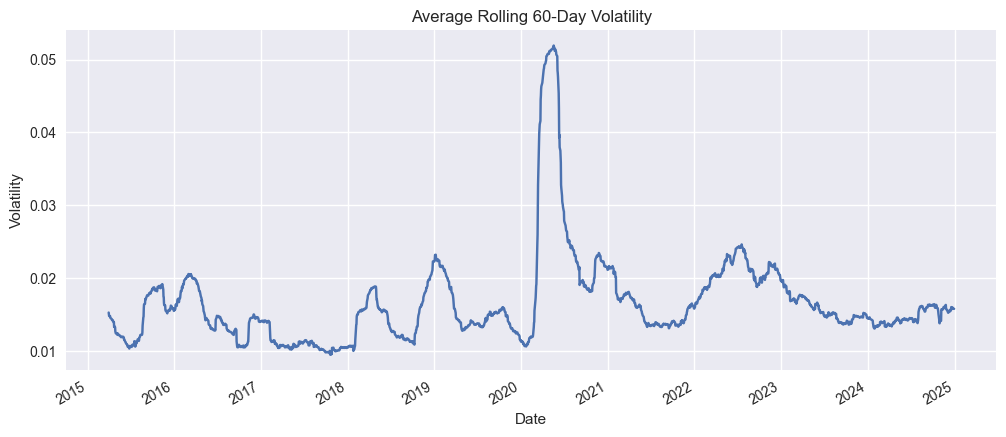

In [14]:
window = 60

rolling_vol = returns.rolling(window).std()

plt.figure(figsize=(12,5))
rolling_vol.mean(axis=1).plot()
plt.title("Average Rolling 60-Day Volatility")
plt.ylabel("Volatility")
plt.show()

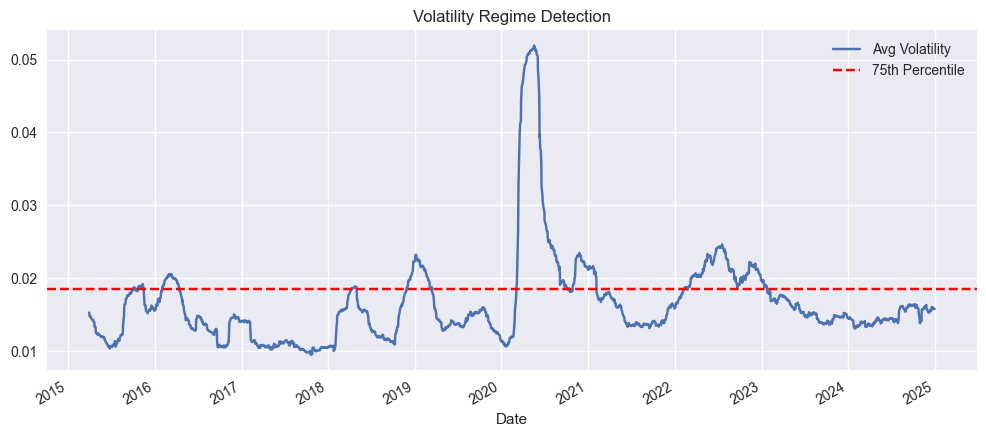

High Volatility Periods: 614


In [15]:
avg_vol = rolling_vol.mean(axis=1)
threshold = avg_vol.quantile(0.75)

high_vol_regime = avg_vol > threshold

plt.figure(figsize=(12,5))
avg_vol.plot(label="Avg Volatility")
plt.axhline(threshold, color='red', linestyle='--', label="75th Percentile")
plt.legend()
plt.title("Volatility Regime Detection")
plt.show()

print("High Volatility Periods:", high_vol_regime.sum())

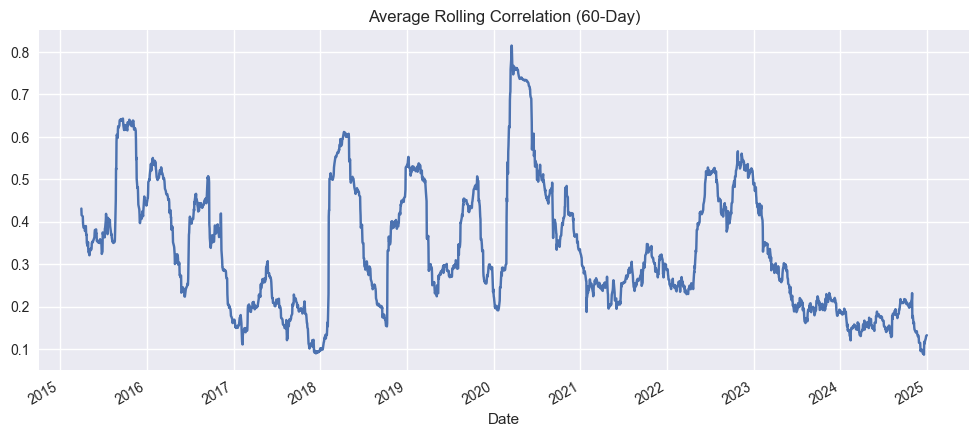

In [16]:
def average_correlation(window_data):
    corr_matrix = window_data.corr()
    upper_triangle = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]
    return upper_triangle.mean()

avg_corr_series = []

for i in range(window, len(returns)):
    window_data = returns.iloc[i-window:i]
    avg_corr_series.append(average_correlation(window_data))

avg_corr_series = pd.Series(avg_corr_series, index=returns.index[window:])

plt.figure(figsize=(12,5))
avg_corr_series.plot()
plt.title("Average Rolling Correlation (60-Day)")
plt.show()

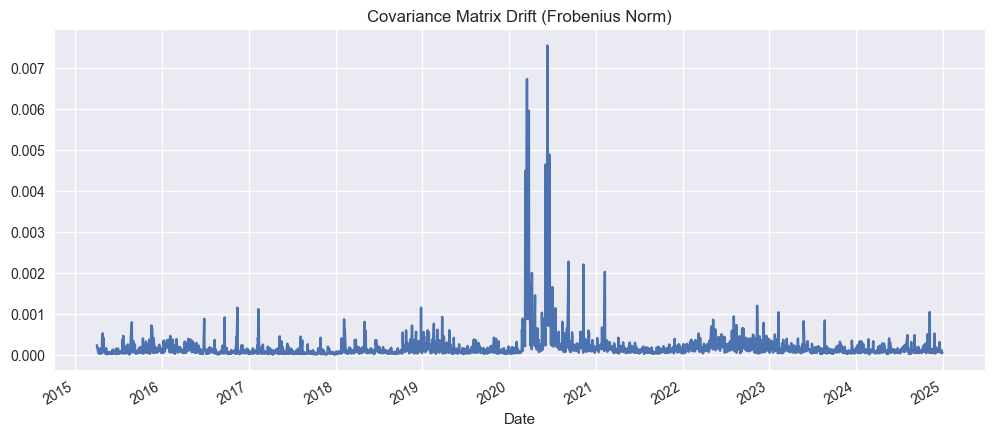

In [17]:
cov_drift = []

for i in range(window+1, len(returns)):
    cov1 = returns.iloc[i-window-1:i-1].cov()
    cov2 = returns.iloc[i-window:i].cov()
    drift = np.linalg.norm(cov2 - cov1)
    cov_drift.append(drift)

cov_drift = pd.Series(cov_drift, index=returns.index[window+1:])

plt.figure(figsize=(12,5))
cov_drift.plot()
plt.title("Covariance Matrix Drift (Frobenius Norm)")
plt.show()

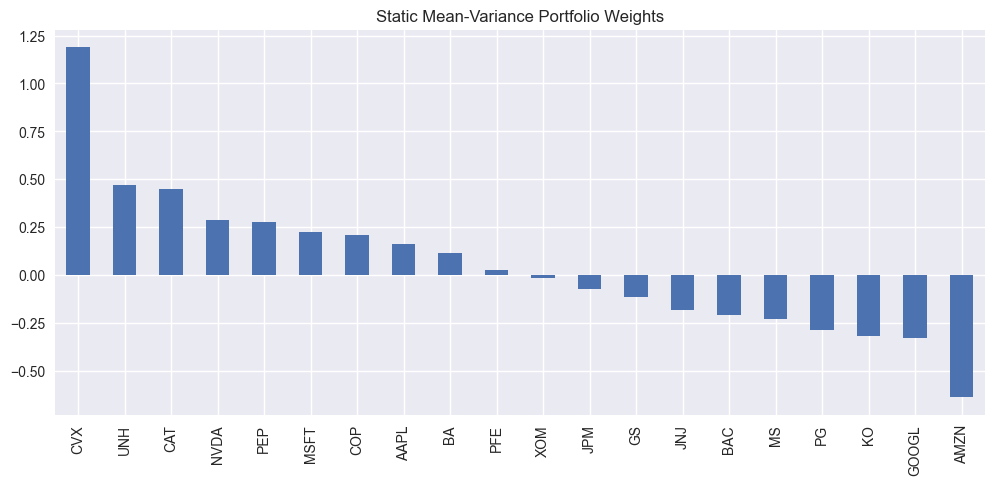

Herfindahl-Hirschman Index (HHI): 2.9837


In [18]:
mu = returns.mean()
Sigma = returns.cov()
lambda_val = 3

inv_Sigma = np.linalg.inv(Sigma.values)

weights = inv_Sigma.dot(mu.values) / lambda_val
weights = weights / weights.sum()

weights = pd.Series(weights, index=tickers)

plt.figure(figsize=(12,5))
weights.sort_values(ascending=False).plot(kind='bar')
plt.title("Static Mean-Variance Portfolio Weights")
plt.show()

HHI = np.sum(weights**2)
print("Herfindahl-Hirschman Index (HHI):", round(HHI, 4))

In [19]:
summary_stats.to_csv("summary_statistics.csv")
avg_corr_series.to_csv("rolling_correlation.csv")
cov_drift.to_csv("covariance_drift.csv")

In [20]:
window = 60

rolling_vol = returns.rolling(window).std()
rolling_vol_mean = rolling_vol.mean(axis=1)

In [21]:
def average_correlation(window_data):
    corr_matrix = window_data.corr()
    upper = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]
    return upper.mean()

avg_corr_series = []

for i in range(window, len(returns)):
    window_data = returns.iloc[i-window:i]
    avg_corr_series.append(average_correlation(window_data))

avg_corr_series = pd.Series(
    avg_corr_series,
    index=returns.index[window:]
)

In [22]:
cov_drift = []

for i in range(window+1, len(returns)):
    cov1 = returns.iloc[i-window-1:i-1].cov()
    cov2 = returns.iloc[i-window:i].cov()
    drift = np.linalg.norm(cov2 - cov1, ord="fro")
    cov_drift.append(drift)

cov_drift = pd.Series(
    cov_drift,
    index=returns.index[window+1:]
)

In [23]:
instability_df = pd.concat(
    [rolling_vol_mean, avg_corr_series, cov_drift],
    axis=1
)

instability_df.columns = ["volatility", "correlation", "cov_drift"]

instability_df = instability_df.dropna()
instability_df.head()

,volatility,correlation,cov_drift
Date,,,
2015-04-02,0.014780,0.415285,0.000239
2015-04-06,0.014780,0.413009,0.000130
2015-04-07,0.014542,0.412330,0.000081
2015-04-08,0.014505,0.395799,0.000165
2015-04-09,0.014446,0.391026,0.000050


In [24]:
instability_z = (instability_df - instability_df.mean()) / instability_df.std()
instability_z.head()

,volatility,correlation,cov_drift
Date,,,
2015-04-02,-0.273730,0.543459,0.134063
2015-04-06,-0.273717,0.528276,-0.145251
2015-04-07,-0.310816,0.523746,-0.270229
2015-04-08,-0.316444,0.413477,-0.055764
2015-04-09,-0.325612,0.381633,-0.349885


In [25]:
instability_index = instability_z.mean(axis=1)
instability_index.name = "Instability_Index"

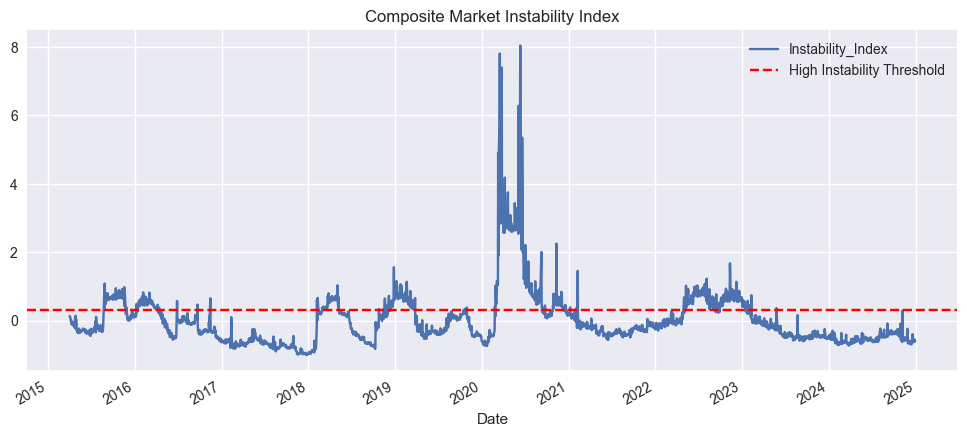

In [26]:
plt.figure(figsize=(12,5))
instability_index.plot()
plt.axhline(instability_index.quantile(0.75), color="red", linestyle="--", label="High Instability Threshold")
plt.legend()
plt.title("Composite Market Instability Index")
plt.show()

In [27]:
print(instability_index.sort_values(ascending=False).head(10))

Date
2020-06-11    8.042274
2020-03-17    7.811445
2020-03-25    7.395241
2020-06-04    6.282521
2020-06-09    5.858608
2020-03-16    5.739361
2020-06-19    5.348904
2020-03-13    5.016573
2020-06-10    4.972684
2020-03-10    4.904187
Name: Instability_Index, dtype: float64
